In [1]:
#!pip install albumentations
#!pip install segmentation_models_pytorch

In [2]:
import cv2
import torch
# import numpy as np
# from torch.utils.data import DataLoader, Dataset
# import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [3]:
from src.utils.config import load_config
from src.utils.helpers import format_number, init_this_notebook, p, data_loader #, load_images_and_masks
cfg = load_config()
init_this_notebook(cfg.SEED)


=== YAML Configuration ===
01: paths:
02:   root: C:\github\Tree-Canopy-Detection
03:   data: src/data
04:   train_images: src/data/train_images
05:   train_images_zip: src/data/train_images.zip
06:   train_masks: src/data/train_masks
07:   eval_images: src/data/evaluation_images
08:   eval_images_zip: src/data/evaluation_images.zip
09:   eval_masks: src/data/eval_masks
10:   models: models
11:   notebooks: notebooks
12: params:
13:   image_size: 512
14:   batch_size: 16
15:   num_workers: 0
16:   seed: 42
17:   epochs: 2
18:   learning_rate: 1e-4

Python: 3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]
Numpy: 1.26.4
Panda: 2.2.2



In [4]:
# ---------------------------------------------------------------
# augmentations and tensor conversion
# ---------------------------------------------------------------
transformer = A.Compose(
    [
        #A.Resize(cfg.IMAGE_SIZE, cfg.IMAGE_SIZE),
        A.Resize(cfg.IMAGE_SIZE, cfg.IMAGE_SIZE),
        #
        # Geometric
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
        A.Affine(scale=(0.9, 1.1), rotate=(-15, 15), shear=(-10, 10), p=0.5),
        #
        # Color and lighting
        A.RandomBrightnessContrast(p=0.5),
        ##A.HueSaturationValue(p=0.5),
        A.CLAHE(p=0.5),  # adaptive histogram equalization
        ##A.RGBShift(p=5),
        #
        # Noise and blur
        # A.GaussianBlur(p=0.5),
        ## A.MotionBlur(p=1),
        ##A.GaussNoise(p=5),
        #
        # Distortions
        A.ElasticTransform(0.1),
        A.GridDistortion(p=0.1),
        A.OpticalDistortion(p=0.1),
        #
        # Normalization and tensor conversion (always last)
        ### A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)



In [25]:
def load_images_and_masks(image_path, mask_path, transform=None):

    images = [
        f
        for f in image_path.glob("*.*")
        if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".tif", ".tiff"]
    ]

    #images = images[:2]
    data = []
    for i, img_path in enumerate(images, 1):

        image = cv2.imread(img_path)
        if image is None:
            p("Failed to read image", img_path, color="red")
            return

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path / img_path.name, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            p("Failed to read mask", mask_path, color="orange")
            return

        if transform:
            augmented = transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        data.append((image, mask))

    p(f"Total (with {"No" if transform is None else ""} transformer)", len(images))
    return data

In [26]:
import hashlib

#hash function for tensors or numpy arrays
def hash_image(img):
    if isinstance(img, torch.Tensor):
        arr = img.cpu().numpy()
    else:
        arr = img
    return hashlib.md5(arr.tobytes()).hexdigest()


In [28]:
# ---------------------------------------------------------------
# load images and masks
# ---------------------------------------------------------------
# train_data = load_images_and_masks(
#     cfg.PATHS_TRAIN_IMAGES, cfg.PATHS_TRAIN_MASKS, transform=transformer
# )
original_data = load_images_and_masks(
    cfg.PATHS_TRAIN_IMAGES, cfg.PATHS_TRAIN_MASKS, transform=None
)

train_data = []
seen_hashes = set()

# Keep all original images
for img, mask in original_data:
    img_hash = hash_image(img)
    train_data.append((img, mask))
    seen_hashes.add(img_hash)

for k in range(3):
    augmented_data = load_images_and_masks(
        cfg.PATHS_TRAIN_IMAGES, cfg.PATHS_TRAIN_MASKS, transform=transformer
    )

    # Add augmented images only if they're different
    for img, mask in augmented_data:
        img_hash = hash_image(img)
        if img_hash not in seen_hashes:
            train_data.append((img, mask))
            seen_hashes.add(img_hash)


p("Total train_data records", len(train_data))

# for i, data in enumerate(train_data, 1):
#     if i == 2:
#         p(i)
#         p("image", f"\n{data[0]}")
#         p("mask", f"\n{data[1]}")

Total (with No transformer): 150
Total (with  transformer): 150
Total (with  transformer): 150
Total (with  transformer): 150
Total train_data records: 600



=== index 85 ===


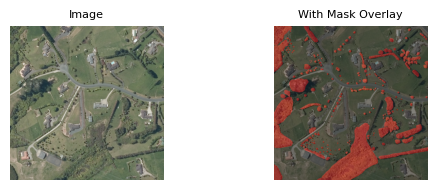

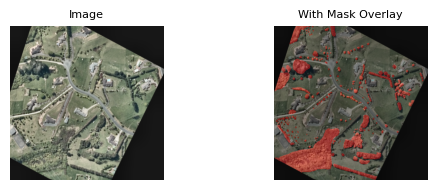


=== index 77 ===


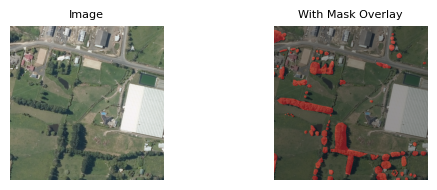

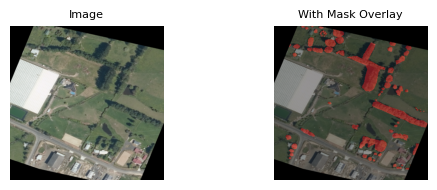

In [34]:
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np


def show_image_with_mask(data, index=0, alpha=0.4):
    """
    Display an image and its corresponding mask from an in-memory dataset.
    """
    # Pick random index if needed
    if index == 0:
        index = random.randint(0, len(data) - 1)

    image, mask = data[index]

    # Convert from torch tensor to numpy if needed
    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).cpu().numpy()
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()

    # Handle normalization or scaling
    if image.max() > 1.0:  # probably uint8 0–255
        image_disp = image.astype(np.uint8)
    else:  # probably normalized to 0–1
        image_disp = (image * 255).astype(np.uint8)

    # Normalize mask values to 0–255
    if mask.max() > 1:
        mask_disp = mask.astype(np.uint8)
    else:
        mask_disp = (mask * 255).astype(np.uint8)

    # Create red overlay for mask (in RGB order)
    mask_rgb = np.zeros_like(image_disp)
    mask_rgb[:, :, 0] = mask_disp  # red channel

    # Blend
    overlay = cv2.addWeighted(image_disp, 1 - alpha, mask_rgb, alpha, 0)

    # Plot
    plt.figure(figsize=(6, 2), dpi=100)
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    if len(data) > 1:
        plt.title(f"Image (index {index})", fontsize=8)
    else:
        plt.title("Image", fontsize=8)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title("With Mask Overlay", fontsize=8)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def show_transform_samples(image, mask, transform, num_samples=3, alpha=0.4):
    """
    Apply an Albumentations transform multiple times and display each result
    using the existing show_image_with_mask function.
    """

    # Convert tensors to numpy if needed
    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).cpu().numpy()
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()

    # Convert to uint8 in case image is in [0,1]
    if image.max() <= 1.0:
        image_disp = (image * 255).astype(np.uint8)
    else:
        image_disp = image.astype(np.uint8)

    if mask.max() <= 1.0:
        mask_disp = (mask * 255).astype(np.uint8)
    else:
        mask_disp = mask.astype(np.uint8)

    show_image_with_mask([(image_disp, mask_disp)], index=0, alpha=alpha)

    # Apply transformations and visualize
    for i in range(num_samples - 1):
        augmented = transform(image=image_disp, mask=mask_disp)
        aug_img, aug_mask = augmented["image"], augmented["mask"]

        # Use your working display function
        show_image_with_mask([(aug_img, aug_mask)], index=0, alpha=alpha)


for n in range(2):
    num = random.randint(1, 150)
    p(f"index {num}")
    sample_image, sample_mask = train_data[num]
    show_transform_samples(sample_image, sample_mask, transformer, num_samples=2)

In [35]:

import segmentation_models_pytorch as smp
import torch

# from torch.utils.data import DataLoader, Dataset


model = smp.Unet(
    encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1
)


criterion = smp.losses.DiceLoss(mode="binary")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

#p(model)


In [36]:
p("EPOCHS",cfg.EPOCHS)
for epoch in range(cfg.EPOCHS):
    model.train()
    total_loss = 0.0

    for images, masks in data_loader(train_data, batch_size=8):
        images = images.to(device).float()
        masks = masks.to(device).float().unsqueeze(1)

        preds = model(images)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    p(f"Epoch {epoch+1}", f"Avg Loss: {total_loss / len(train_data):.6f}")



EPOCHS: 2


TypeError: expected Tensor as element 0 in argument 0, but got numpy.ndarray

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()
with torch.no_grad():
    img, mask = train_data[0]

    # ensure tensor is float32 and batch dimension added
    img = img.float().unsqueeze(0).to(device)

    pred = torch.sigmoid(model(img)).cpu().squeeze().numpy()

# move back to CPU and convert for display
img_np = img.cpu().squeeze().permute(1, 2, 0).numpy()
img_np = np.clip(img_np / 255.0, 0, 1)

mask_np = mask.cpu().squeeze().numpy()


plt.figure(figsize=(12, 6), dpi=100)

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title("Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_np, cmap="gray")
plt.title("Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred > 0.5, cmap="gray")
plt.title("Prediction Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
def visualize_prediction(model, data, device, index=0, threshold=0.5):
    with torch.no_grad():
        img, mask = data[index]
        img = img.float().unsqueeze(0).to(device)
        pred = torch.sigmoid(model(img)).cpu().squeeze().numpy()

    img_np = img.cpu().squeeze().permute(1, 2, 0).numpy()
    img_np = np.clip(img_np, 0, 1)
    mask_np = mask.cpu().squeeze().numpy()

    plt.figure(figsize=(12, 6), dpi=200)
    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title("Input")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Truth Mask")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(pred > threshold, cmap="gray")
    plt.title("Prediction Mask")
    
    plt.axis("off")
    plt.tight_layout()
    plt.show()


for i in [0, 5, 10]:
    visualize_prediction(model, train_data, device, index=i)

NameError: name 'model' is not defined